# Student Performance Prediction Analysis Using Machine Learning and Artificial Neural Networks

**Student:** Dragana Ivanova

## Project Objective

The objective of this project is to develop and compare machine learning models for predicting student mathematics exam scores based on demographic, social, and educational characteristics.

The models that will be compared are:

1. Linear Regression
2. Random Forest Regressor
3. Artificial Neural Network (ANN)

The models will be evaluated using MAE, MSE, RMSE, and R².

In [1]:
# Import pandas for working with tabular data
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib and Seaborn for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

# Import the Random Forest Regression model
from sklearn.ensemble import RandomForestRegressor

# Import evaluation metrics for regression models
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Import TensorFlow and Keras for building the Artificial Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


**Problem statement**

The objective of this project is to predict students mathematics score based on demographic and educational characteristics. Several  machine learning regression algorithms are developed and compared to determine which model best predicts academic performance while identifying the most influental factors.


In [ ]:
# Load the Students Performance dataset
df = pd.read_csv("StudentsPerformance.csv")

# Confirm that the dataset was loaded successfully
print("Dataset loaded successfully!")
df.head()


## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure and characteristics of the dataset before applying machine learning algorithms.

The analysis focuses on:

- The distribution of students' mathematics, reading, and writing scores.
- The distribution of categorical variables.
- Relationships between students' examination scores.
- Potential relationships between student characteristics and mathematics performance.

The findings from this analysis will help guide the data preprocessing and machine learning stages of the project.

In [7]:
# Define the numerical score variables
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

# Define the categorical variables
categorical_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

In [8]:
# Display summary statistics for the examination scores
df[score_columns].describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


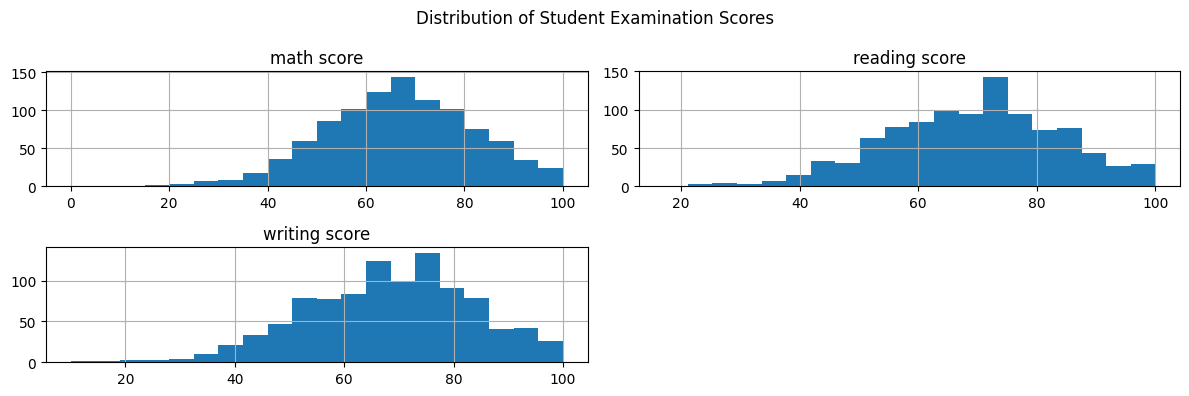

In [9]:
# Create histograms for mathematics, reading, and writing scores
df[score_columns].hist(
    figsize=(12, 4),
    bins=20
)

plt.suptitle("Distribution of Student Examination Scores")
plt.tight_layout()
plt.show()

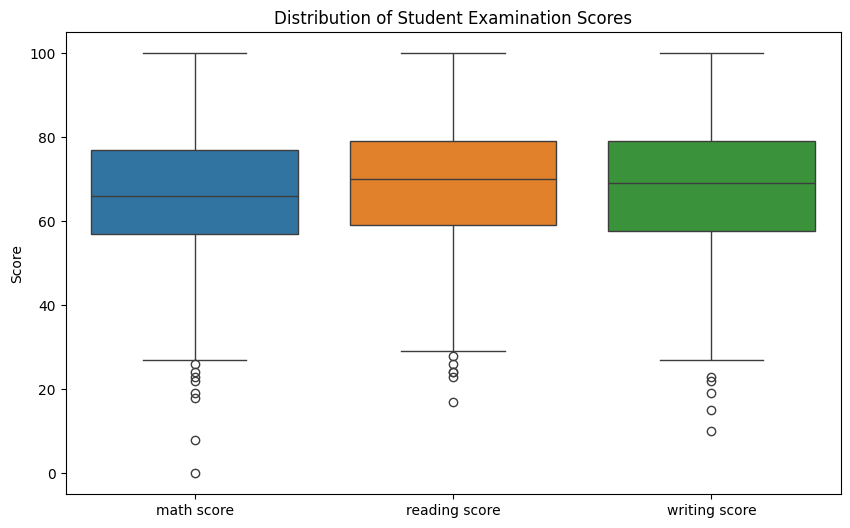

In [10]:
# Create boxplots to visualize score distributions and potential outliers
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[score_columns])

plt.title("Distribution of Student Examination Scores")
plt.ylabel("Score")

plt.show()

In [11]:
# Display the number of observations in each category
for column in categorical_columns:
    print(f"\nValue counts for: {column}")
    print(df[column].value_counts())



Value counts for: gender
gender
female    518
male      482
Name: count, dtype: int64

Value counts for: race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Value counts for: parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Value counts for: lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Value counts for: test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [12]:
# Compare mathematics scores based on test preparation course completion
test_preparation_math = df.groupby(
    "test preparation course"
)["math score"].agg(
    ["count", "mean", "median", "std"]
)

test_preparation_math

,count,mean,median,std
test preparation course,,,,
completed,358,69.695531,69.0,14.444699
none,642,64.077882,64.0,15.192376


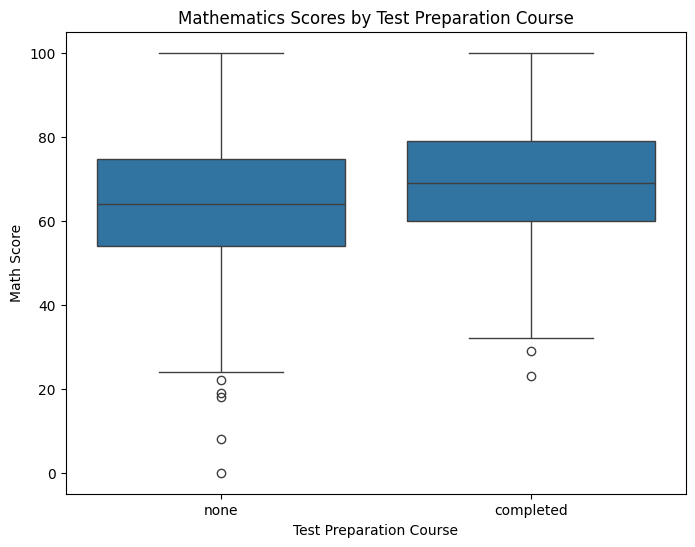

In [13]:
# Visualize mathematics scores by test preparation course status
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score"
)

plt.title("Mathematics Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

plt.show()

In [14]:
# Calculate the average mathematics score for each parental education level
parental_education_math = df.groupby(
    "parental level of education"
)["math score"].mean().sort_values(ascending=False)

parental_education_math

,math score
parental level of education,
master's degree,69.745763
bachelor's degree,69.389831
associate's degree,67.882883
some college,67.128319
some high school,63.497207
high school,62.137755


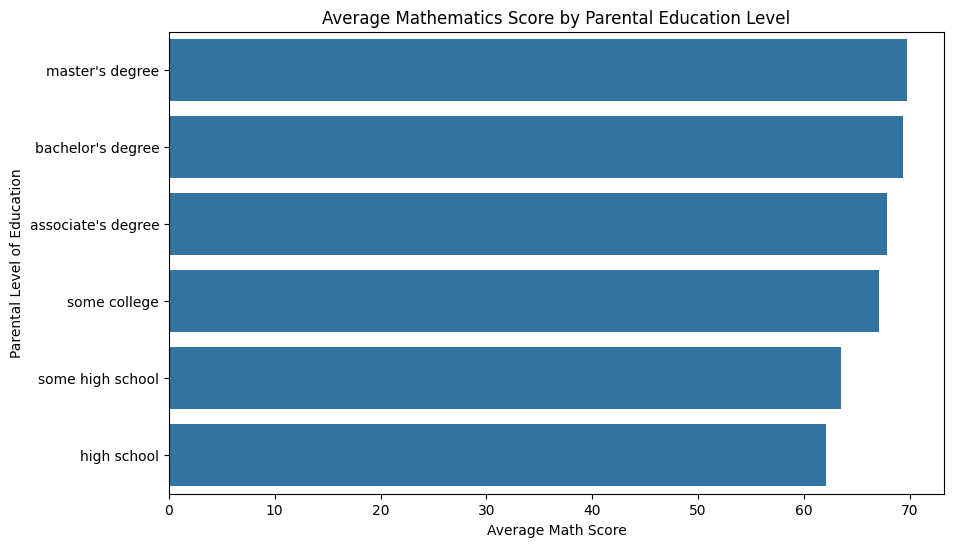

In [15]:
# Visualize average mathematics scores by parental education level
plt.figure(figsize=(10, 6))

sns.barplot(
    x=parental_education_math.values,
    y=parental_education_math.index
)

plt.title("Average Mathematics Score by Parental Education Level")
plt.xlabel("Average Math Score")
plt.ylabel("Parental Level of Education")

plt.show()

In [16]:
# Calculate the average mathematics score by lunch type
lunch_math = df.groupby(
    "lunch"
)["math score"].mean()

lunch_math

,math score
lunch,
free/reduced,58.921127
standard,70.034109


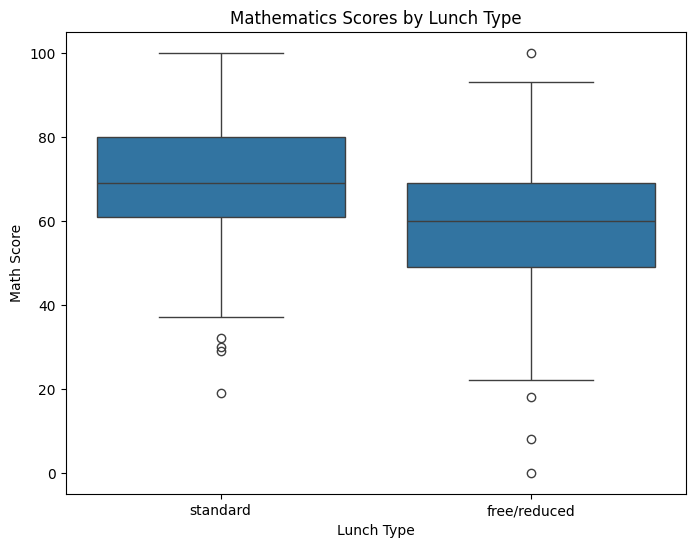

In [17]:
# Visualize mathematics scores by lunch type
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="lunch",
    y="math score"
)

plt.title("Mathematics Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Math Score")

plt.show()

In [18]:
# Calculate the average mathematics score by gender
gender_math = df.groupby(
    "gender"
)["math score"].mean()

gender_math

,math score
gender,
female,63.633205
male,68.728216


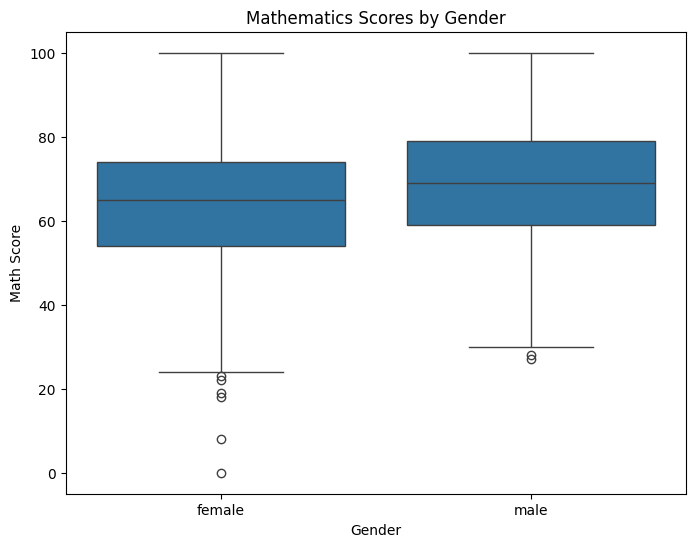

In [19]:
# Visualize mathematics scores by gender
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="gender",
    y="math score"
)

plt.title("Mathematics Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")

plt.show()

In [20]:
# Calculate the correlation matrix for examination scores
score_correlation = df[score_columns].corr()

score_correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


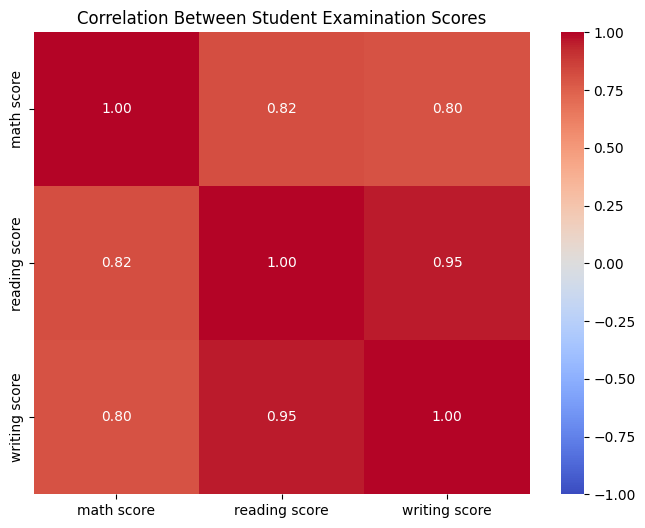

In [21]:
# Visualize correlations between mathematics, reading, and writing scores
plt.figure(figsize=(8, 6))

sns.heatmap(
    score_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Student Examination Scores")

plt.show()

In [22]:
# Calculate average mathematics scores for each categorical variable
for column in categorical_columns:
    print(f"\nAverage Mathematics Score by {column}:")
    print(
        df.groupby(column)["math score"]
        .mean()
        .sort_values(ascending=False)
    )


Average Mathematics Score by gender:
gender
male      68.728216
female    63.633205
Name: math score, dtype: float64

Average Mathematics Score by race/ethnicity:
race/ethnicity
group E    73.821429
group D    67.362595
group C    64.463950
group B    63.452632
group A    61.629213
Name: math score, dtype: float64

Average Mathematics Score by parental level of education:
parental level of education
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755
Name: math score, dtype: float64

Average Mathematics Score by lunch:
lunch
standard        70.034109
free/reduced    58.921127
Name: math score, dtype: float64

Average Mathematics Score by test preparation course:
test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64


In [23]:
# Compare average mathematics scores by lunch type and test preparation course
lunch_test_prep_math = df.groupby(
    ["lunch", "test preparation course"]
)["math score"].mean().reset_index()

lunch_test_prep_math

,lunch,test preparation course,math score
0,free/reduced,completed,63.045802
1,free/reduced,none,56.508929
2,standard,completed,73.533040
3,standard,none,68.133971


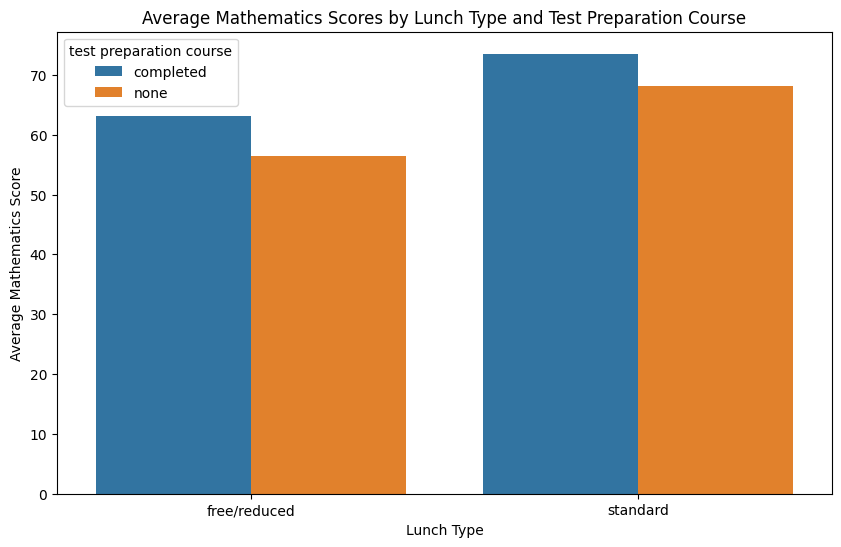

In [24]:
# Visualize the combined relationship between lunch type,
# test preparation course, and mathematics performance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lunch_test_prep_math,
    x="lunch",
    y="math score",
    hue="test preparation course"
)

plt.title(
    "Average Mathematics Scores by Lunch Type and Test Preparation Course"
)
plt.xlabel("Lunch Type")
plt.ylabel("Average Mathematics Score")

plt.show()

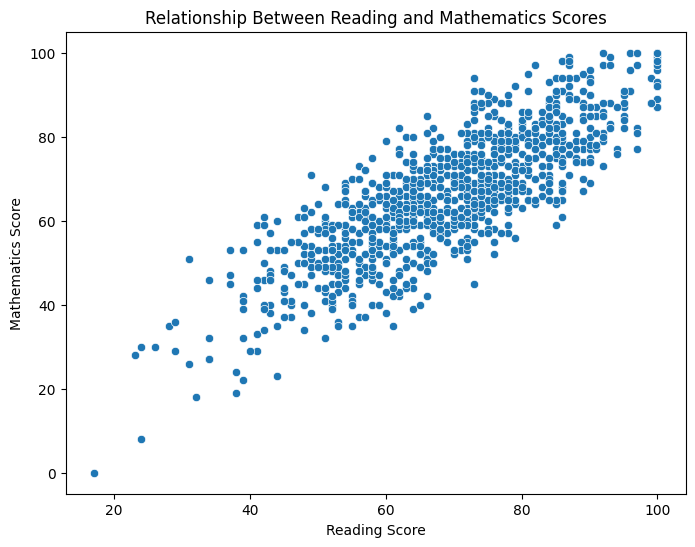

In [25]:
# Visualize the relationship between reading and mathematics scores
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="reading score",
    y="math score"
)

plt.title("Relationship Between Reading and Mathematics Scores")
plt.xlabel("Reading Score")
plt.ylabel("Mathematics Score")

plt.show()

EDA Summary

The exploratory data analysis revealed several patterns in student mathematics performance. Mathematics scores showed a strong positive relationship with reading and writing scores, indicating that students who perform well in one examination area tend to perform well in the others. Differences in mathematics performance were also observed across demographic, social, and educational characteristics. In particular, test preparation course completion, parental level of education, and lunch type showed potential associations with mathematics performance. These findings support the use of these variables as predictors in the machine learning models. The results of the EDA provide a basis for the next stage of the project, where the categorical variables will be encoded and the dataset will be prepared for machine learning.

## 5. Data Preprocessing

Before training the machine learning models, the dataset must be prepared for analysis. The mathematics score is defined as the target variable, while demographic, social, and educational characteristics are used as predictor variables.

The categorical predictor variables are converted into numerical representations using one-hot encoding. The dataset is then divided into training and testing subsets. The training set is used to train the models, while the testing set is used to evaluate their performance on unseen data.

In [26]:
# Define the target variable
# The goal of the project is to predict mathematics scores
y = df["math score"]

# Define the predictor variables
# Reading and writing scores are excluded because the project focuses
# on predicting mathematics performance from demographic, social,
# and educational characteristics
feature_columns = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course"
]

X = df[feature_columns]

# Display the first five rows of the predictor variables
X.head()
y.head()

,math score
0,72
1,69
2,90
3,47
4,76


In [27]:
# Check for missing values in the predictor variables
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
dtype: int64

Missing values in target:
0


In [28]:
# Convert categorical variables into numerical dummy variables
X_encoded = pd.get_dummies(
    X,
    columns=feature_columns,
    drop_first=True
)

# Display the first five rows of the encoded dataset
X_encoded.head()
# Display the names of the encoded features
print("Encoded feature columns:")
print(X_encoded.columns.tolist())

# Display the shape of the encoded dataset
print("\nShape of encoded features:", X_encoded.shape)
# Check the data types of the encoded features
X_encoded.dtypes
# Convert encoded Boolean values to integers
X_encoded = X_encoded.astype(int)

# Check the updated data types
X_encoded.dtypes
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the resulting datasets
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)
# Display a sample of the training features
print("Sample of training features:")
display(X_train.head())

# Display a sample of the training target
print("\nSample of training target:")
display(y_train.head())


Encoded feature columns:
['gender_male', 'race/ethnicity_group B', 'race/ethnicity_group C', 'race/ethnicity_group D', 'race/ethnicity_group E', "parental level of education_bachelor's degree", 'parental level of education_high school', "parental level of education_master's degree", 'parental level of education_some college', 'parental level of education_some high school', 'lunch_standard', 'test preparation course_none']

Shape of encoded features: (1000, 12)
Training features shape: (800, 12)
Testing features shape: (200, 12)
Training target shape: (800,)
Testing target shape: (200,)
Sample of training features:


,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
29,0,0,0,1,0,0,0,1,0,0,1,1
535,0,0,1,0,0,1,0,0,0,0,0,0
695,0,0,0,1,0,0,0,0,1,0,0,1
557,1,0,1,0,0,0,0,1,0,0,0,1
836,1,0,0,0,1,0,1,0,0,0,1,1



Sample of training target:


,math score
29,62
535,66
695,79
557,61
836,73



## 6. Linear Regression Model

Linear Regression is used as the first machine learning model to establish a baseline for predicting students' mathematics examination scores. The model estimates the relationship between the predictor variables and the target variable by fitting a linear equation to the training data. The trained model is then evaluated on the testing dataset using several regression performance metrics.

In [29]:
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance (1).csv


In [30]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [31]:
# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [32]:
# Predict mathematics scores for the testing dataset
y_pred_linear = linear_model.predict(X_test)

print("First 10 predicted mathematics scores:")
print(np.round(y_pred_linear[:10], 2))

First 10 predicted mathematics scores:
[65.34 59.13 75.99 58.2  84.07 61.35 63.79 67.9  58.34 72.42]


In [33]:
# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print(f"MAE:  {linear_mae:.2f}")
print(f"MSE:  {linear_mse:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²:   {linear_r2:.2f}")

Linear Regression Performance
MAE:  11.27
MSE:  200.51
RMSE: 14.16
R²:   0.18


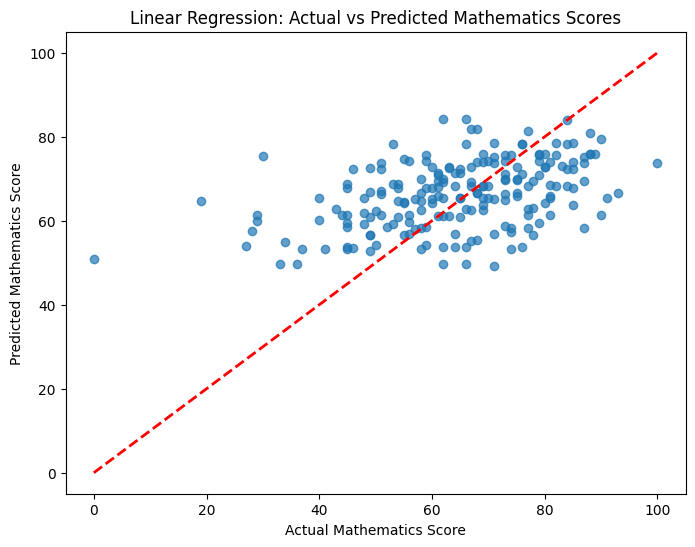

In [34]:
# Plot actual versus predicted mathematics scores
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("Linear Regression: Actual vs Predicted Mathematics Scores")
plt.xlabel("Actual Mathematics Score")
plt.ylabel("Predicted Mathematics Score")

plt.show()

In [35]:
# Create a comparison table
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": np.round(y_pred_linear, 2)
})

comparison.head(10)

,Actual Score,Predicted Score
0,91,65.34
1,53,59.13
2,80,75.99
3,74,58.20
4,84,84.07
5,81,61.35
6,69,63.79
7,54,67.90
8,87,58.34
9,51,72.42


### Linear Regression Results

The Linear Regression model achieved a Mean Absolute Error (MAE) of 11.27, a Mean Squared Error (MSE) of 200.51, a Root Mean Squared Error (RMSE) of 14.16, and an R² score of 0.18.

These results indicate that the model is able to capture some of the relationship between the demographic, social, and educational characteristics and students' mathematics performance. However, the relatively low R² value suggests that a linear relationship alone is not sufficient to explain much of the variation in mathematics scores. More advanced models, such as Random Forest and Artificial Neural Networks, may capture more complex relationships and achieve better predictive performance.

## 7. Random Forest Regressor

The Random Forest Regressor is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Unlike Linear Regression, Random Forest can capture complex and non-linear relationships between the predictor variables and students' mathematics performance.

The model is trained using the training dataset and evaluated on the testing dataset using the same performance metrics as the Linear Regression model.

In [36]:
# Create a Random Forest Regressor
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [37]:
# Predict mathematics scores for the testing dataset
y_pred_rf = random_forest_model.predict(X_test)

# Display the first 10 predictions
print("First 10 predicted mathematics scores:")
print(np.round(y_pred_rf[:10], 2))

First 10 predicted mathematics scores:
[62.52 65.42 66.08 62.5  88.35 61.24 68.62 52.76 61.63 71.64]


In [38]:
# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"MAE:  {rf_mae:.2f}")
print(f"MSE:  {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.2f}")

Random Forest Performance
MAE:  12.40
MSE:  247.47
RMSE: 15.73
R²:   -0.02


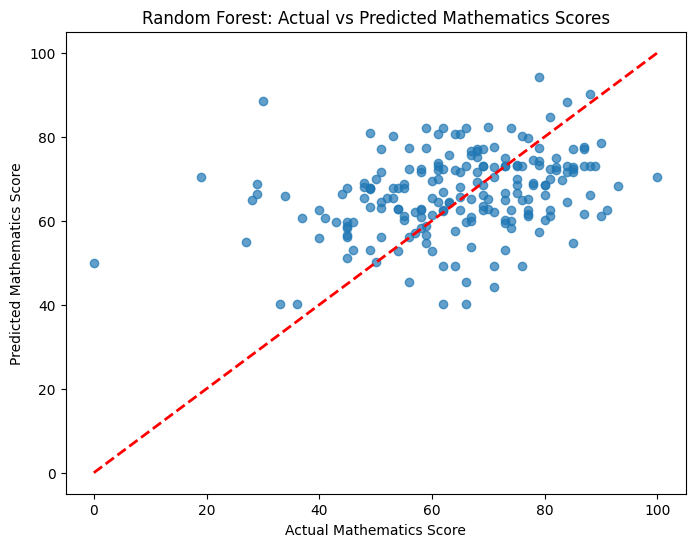

In [39]:
# Plot actual versus predicted mathematics scores
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("Random Forest: Actual vs Predicted Mathematics Scores")
plt.xlabel("Actual Mathematics Score")
plt.ylabel("Predicted Mathematics Score")

plt.show()

In [40]:
# Calculate feature importance
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,lunch_standard,0.251901
11,test preparation course_none,0.101874
0,gender_male,0.099604
4,race/ethnicity_group E,0.091060
6,parental level of education_high school,0.063694
2,race/ethnicity_group C,0.061813
1,race/ethnicity_group B,0.061485
5,parental level of education_bachelor's degree,0.061051
8,parental level of education_some college,0.059691
9,parental level of education_some high school,0.057304


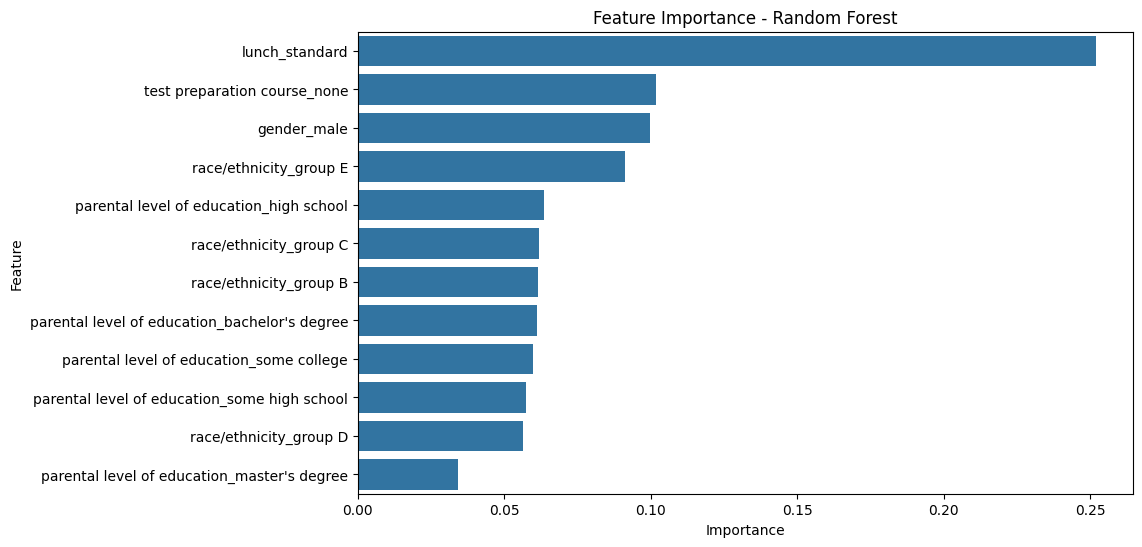

In [41]:
# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Random Forest Results

The Random Forest Regressor achieved a Mean Absolute Error (MAE) of 12.40, a Mean Squared Error (MSE) of 247.47, a Root Mean Squared Error (RMSE) of 15.73, and an R² score of -0.02.

Compared with the Linear Regression model, the Random Forest Regressor produced lower predictive performance on this dataset. The negative R² value indicates that the model did not generalize well to the testing data and performed worse than predicting the average mathematics score. This suggests that the selected predictor variables and the default Random Forest settings were not sufficient to capture meaningful patterns in the data. Nevertheless, the model provides useful feature importance information that helps identify the variables contributing most to the predictions.

## 8. Artificial Neural Network (ANN)

In addition to the proposed models, an Artificial Neural Networks was implemented to investigate whether a deep learning approach could improve predictive performance.
An Artificial Neural Network (ANN) is a machine learning model inspired by the structure of the human brain. Unlike Linear Regression and Random Forest, neural networks can learn complex and non-linear relationships between variables through multiple interconnected layers of neurons.

Before training the ANN, the predictor variables are standardized to improve training stability and model performance.

In [43]:
from sklearn.preprocessing import StandardScaler

In [44]:
# Create a scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both datasets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed successfully!")

Data scaling completed successfully!


In [45]:
# Create the ANN model
ann_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation="relu"),
    layers.Dense(1)
])

# Compile the model
ann_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Display model summary
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Train the ANN model
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 4688.8457 - mae: 66.8106 - val_loss: 4635.3477 - val_mae: 66.3667
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4640.1040 - mae: 66.4436 - val_loss: 4588.5093 - val_mae: 66.0116
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4594.0532 - mae: 66.0946 - val_loss: 4543.1670 - val_mae: 65.6646
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4547.1455 - mae: 65.7362 - val_loss: 4495.1782 - val_mae: 65.2938
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4495.8096 - mae: 65.3426 - val_loss: 4440.0405 - val_mae: 64.8652
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4436.2500 - mae: 64.8831 - val_loss: 4376.7607 - val_mae: 64.3685
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4366.6001 - mae: 64.3396 - val_loss: 4305.4346 - val_mae: 63.8029
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 4288.1592 - mae: 63.7197 - val_loss: 4224.5488 - val_mae: 63.1541
Ep

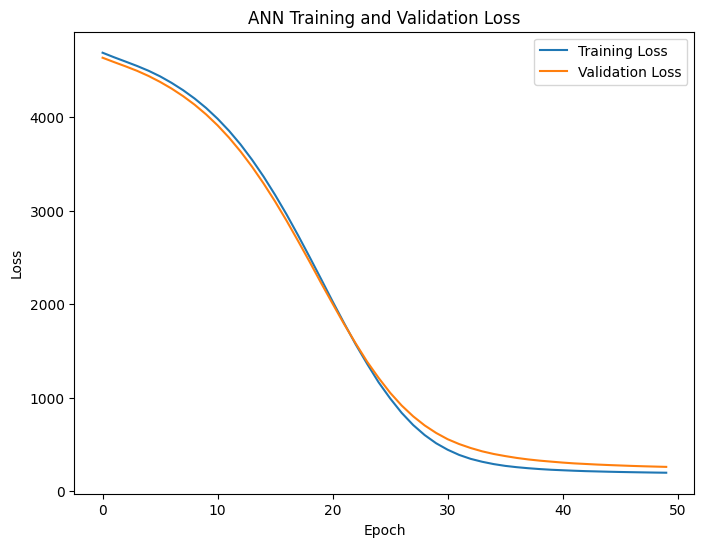

In [47]:
# Plot training and validation loss
plt.figure(figsize=(8, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [48]:
# Predict mathematics scores
y_pred_ann = ann_model.predict(X_test_scaled)

# Flatten predictions
y_pred_ann = y_pred_ann.flatten()

print("First 10 predicted scores:")
print(np.round(y_pred_ann[:10], 2))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
First 10 predicted scores:
[59.11 51.33 71.34 57.57 73.37 59.33 44.33 56.56 52.77 53.31]


In [49]:
# Calculate evaluation metrics
ann_mae = mean_absolute_error(y_test, y_pred_ann)
ann_mse = mean_squared_error(y_test, y_pred_ann)
ann_rmse = np.sqrt(ann_mse)
ann_r2 = r2_score(y_test, y_pred_ann)

print("ANN Performance")
print(f"MAE:  {ann_mae:.2f}")
print(f"MSE:  {ann_mse:.2f}")
print(f"RMSE: {ann_rmse:.2f}")
print(f"R²:   {ann_r2:.2f}")

ANN Performance
MAE:  12.80
MSE:  274.38
RMSE: 16.56
R²:   -0.13


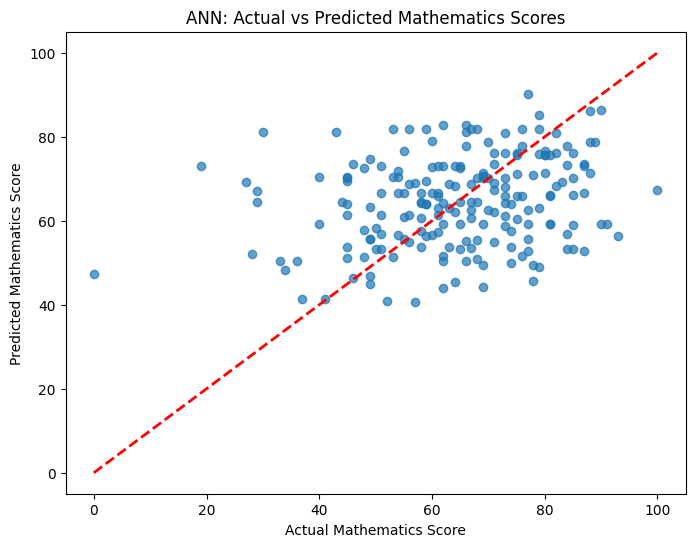

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_ann, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.title("ANN: Actual vs Predicted Mathematics Scores")
plt.xlabel("Actual Mathematics Score")
plt.ylabel("Predicted Mathematics Score")

plt.show()

## 9. Model Evaluation

After training the three machine learning models, their predictive performance was evaluated using four regression metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

These metrics provide an objective comparison of the models. Lower values of MAE, MSE, and RMSE indicate better prediction accuracy, while a higher R² value indicates that the model explains a greater proportion of the variation in students' mathematics scores.

## 10. Model Comparison

The performance of the Linear Regression, Random Forest Regressor, and Artificial Neural Network models was compared using the evaluation metrics calculated on the testing dataset. The comparison identifies the model that achieved the best predictive performance for this dataset.

In [54]:
# Create a comparison table
comparison_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Artificial Neural Network"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        ann_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse,
        ann_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        ann_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2,
        ann_r2
    ]
})

comparison_results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,11.269873,200.510846,14.160185,0.176000
1,Random Forest,12.397728,247.468275,15.731124,-0.016972
2,Artificial Neural Network,12.798517,274.380066,16.564422,-0.127566


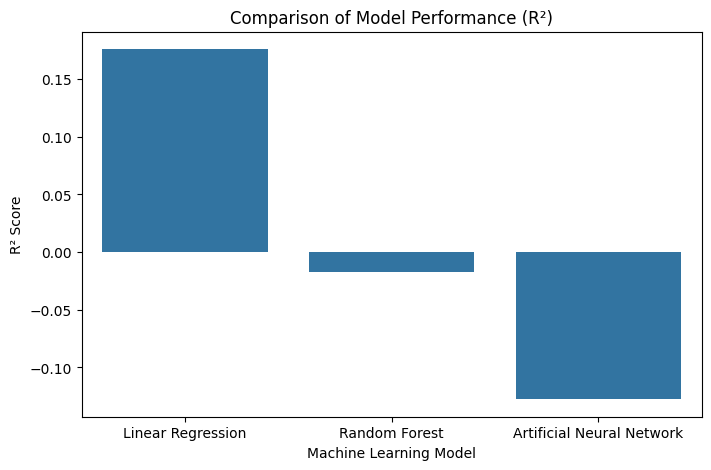

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_results,
    x="Model",
    y="R²"
)

plt.title("Comparison of Model Performance (R²)")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.show()

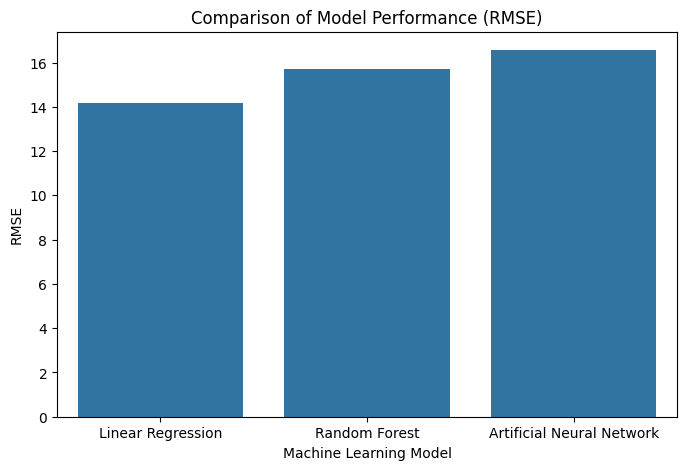

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_results,
    x="Model",
    y="RMSE"
)

plt.title("Comparison of Model Performance (RMSE)")
plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")

plt.show()


**Limitations**

The dataset contains only 1000 observations and a limited number of demographic variables. important factors such as attendance, study habits, socioeconomic background, and classroom performance are unavailable.These limitations may restrict the predictive capability of the models.

## 11. Discussion

The comparison of the three machine learning models showed that Linear Regression achieved the best overall performance on this dataset. It produced the lowest MAE, MSE, and RMSE values, together with the highest R² score.

Although Random Forest and the Artificial Neural Network are more advanced machine learning techniques, they did not outperform Linear Regression. This outcome suggests that the available predictor variables mainly exhibit relatively simple relationships with students' mathematics scores. Additionally, the dataset contains only 1000 observations, which may limit the ability of more complex models to learn meaningful patterns.

These findings demonstrate that a simpler model can sometimes provide better predictive performance than more sophisticated algorithms, particularly when working with relatively small datasets and a limited number of predictor variables.

## 12. Conclusion

The objective of this project was to develop and compare machine learning models for predicting students' mathematics examination scores using demographic, social, and educational characteristics.

Three models were implemented: Linear Regression, Random Forest Regressor, and an Artificial Neural Network. Each model was evaluated using MAE, MSE, RMSE, and R².

Among the evaluated models, Linear Regression achieved the best overall predictive performance. Random Forest and the Artificial Neural Network produced lower accuracy on this dataset, indicating that the available predictor variables were not sufficient for these more complex models to outperform the simpler linear approach.

Overall, the project demonstrates the complete machine learning workflow, including data exploration, preprocessing, model development, evaluation, and comparison. Future work could improve prediction accuracy by incorporating additional student-related variables and performing more extensive hyperparameter tuning of the machine learning models.